In [1]:
%%capture
%run "imports&preprocessing_problem_1.ipynb"

**Problem 1.3**

In [4]:
# Determine for each stop, by which routes it is served
# treating route_short_name as unique route identifier, station as stop identifier

# 1. Link each stop to its route
station_route_ids = (
    stop_times[['trip_id', 'station']]
    .merge(trips[['trip_id', 'route_id']], on='trip_id')
    [['station', 'route_id']]
    .drop_duplicates()
)

# 2. Add route name and type
station_routes = (
    station_route_ids
    .merge(routes[['route_id', 'route_short_name', 'route_desc']], on='route_id')
    [['station', 'route_short_name', 'route_desc']]
    .drop_duplicates()
)

# 3. Add station name
station_routes = station_routes.merge(
    stops[['stop_id', 'stop_name']],
    left_on='station', right_on='stop_id'
).drop(columns='stop_id')


routes_per_station = (
    station_routes
    .groupby(['station', 'stop_name'])['route_short_name']
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
    .rename(columns={'route_short_name': 'routes'})
)
routes_per_station['num_routes'] = routes_per_station['routes'].apply(len)
routes_per_station = routes_per_station.sort_values('num_routes', ascending=False).reset_index(drop=True)

routes_per_station


,station,stop_name,routes,num_routes
0,de:09162:50,Sendlinger Tor,"[16, 17, 18, 19, 27, 28, 52, 62, N17, N27, N40...",19
1,de:09162:1,Karlsplatz (Stachus),"[16, 17, 18, 19, 20, 21, 27, 28, N17, N19, N20...",17
2,de:09162:5,Ostbahnhof,"[100, 145, 21, 54, 55, 58, 62, 68, N19, N43, N...",16
3,de:09162:6,Hauptbahnhof,"[16, 17, 18, 19, 20, N17, N19, N20, U1, U2, U4...",14
4,de:09162:10,Pasing Bf.,"[130, 14, 157, 159, 160, 162, 19, 56, 57, N19,...",13
...,...,...,...,...
1210,de:09162:1643,Fischer-v.-Erlach-Straße,[57],1
1211,de:09162:1644,Mitterfeldstraße,[57],1
1212,de:09162:1646,Stroblstraße,[57],1
1213,de:09162:1024,Anneliese-Fleyenschmidt-Str,[139],1


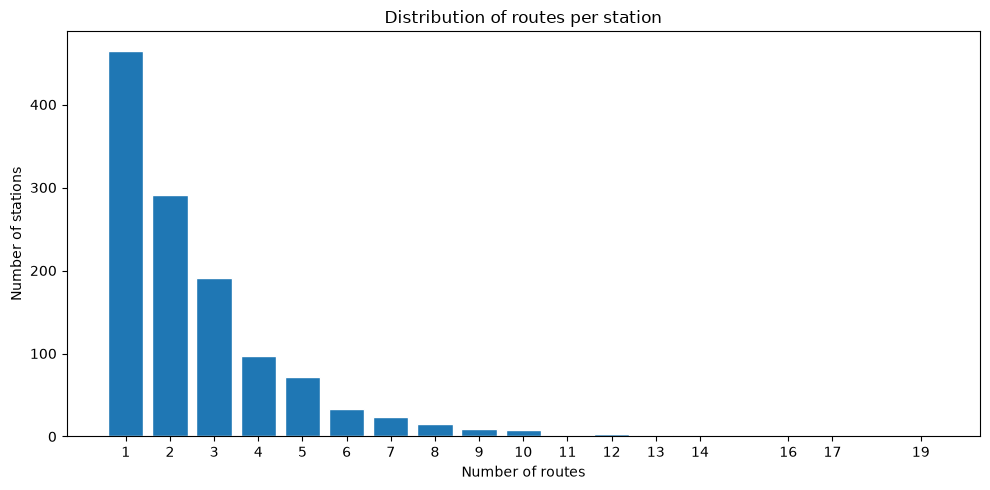

In [10]:
# What is the distribution over the number of routes that serve the stops?

fig, ax = plt.subplots(figsize=(10, 5))

counts = routes_per_station['num_routes'].value_counts().sort_index()
ax.bar(counts.index, counts.values, edgecolor='white')

ax.set_xlabel('Number of routes')
ax.set_ylabel('Number of stations')
ax.set_title('Distribution of routes per station')
ax.set_xticks(counts.index)

plt.tight_layout()
plt.show()


The distribution is heavily right-skewed: most stations are served by very few routes, while only a few stations are served by more than 5 routes 

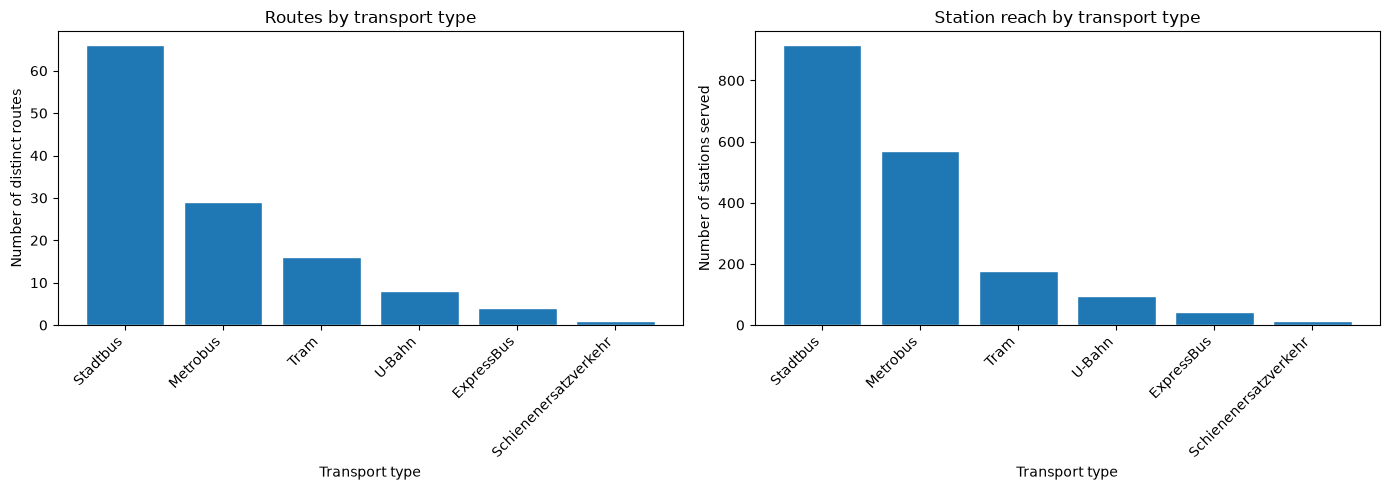

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# distinct routes per type
routes_by_type = station_routes.groupby('route_desc')['route_short_name'].nunique().sort_values(ascending=False)
ax1.bar(routes_by_type.index, routes_by_type.values, edgecolor='white')
ax1.set_xlabel('Transport type')
ax1.set_ylabel('Number of distinct routes')
ax1.set_title('Routes by transport type')
ax1.set_xticks(range(len(routes_by_type)))
ax1.set_xticklabels(routes_by_type.index, rotation=45, ha='right')

# distinct stations per type
stations_by_type = station_routes.groupby('route_desc')['station'].nunique().sort_values(ascending=False)
ax2.bar(stations_by_type.index, stations_by_type.values, edgecolor='white')
ax2.set_xlabel('Transport type')
ax2.set_ylabel('Number of stations served')
ax2.set_title('Station reach by transport type')
ax2.set_xticks(range(len(stations_by_type)))
ax2.set_xticklabels(stations_by_type.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Problem 1.4**

In [19]:
def to_hours(t):
    h, m, s = t.split(':')
    return int(h) + int(m) / 60 + int(s) / 3600

calls = (
    stop_times[['trip_id', 'station', 'arrival_time']]
    .merge(trips[['trip_id', 'route_id', 'service_id']], on='trip_id')
    .merge(routes[['route_id', 'route_desc']].drop_duplicates(), on='route_id')
)

calls['hour'] = calls['arrival_time'].apply(to_hours)
calls['day_type'] = calls['service_id'].map({'SWD': 'Weekday', 'SWE': 'Weekend'})

print(calls.shape)
print(calls['day_type'].value_counts())

(1150460, 8)
day_type
Weekend    766325
Weekday    384135
Name: count, dtype: int64


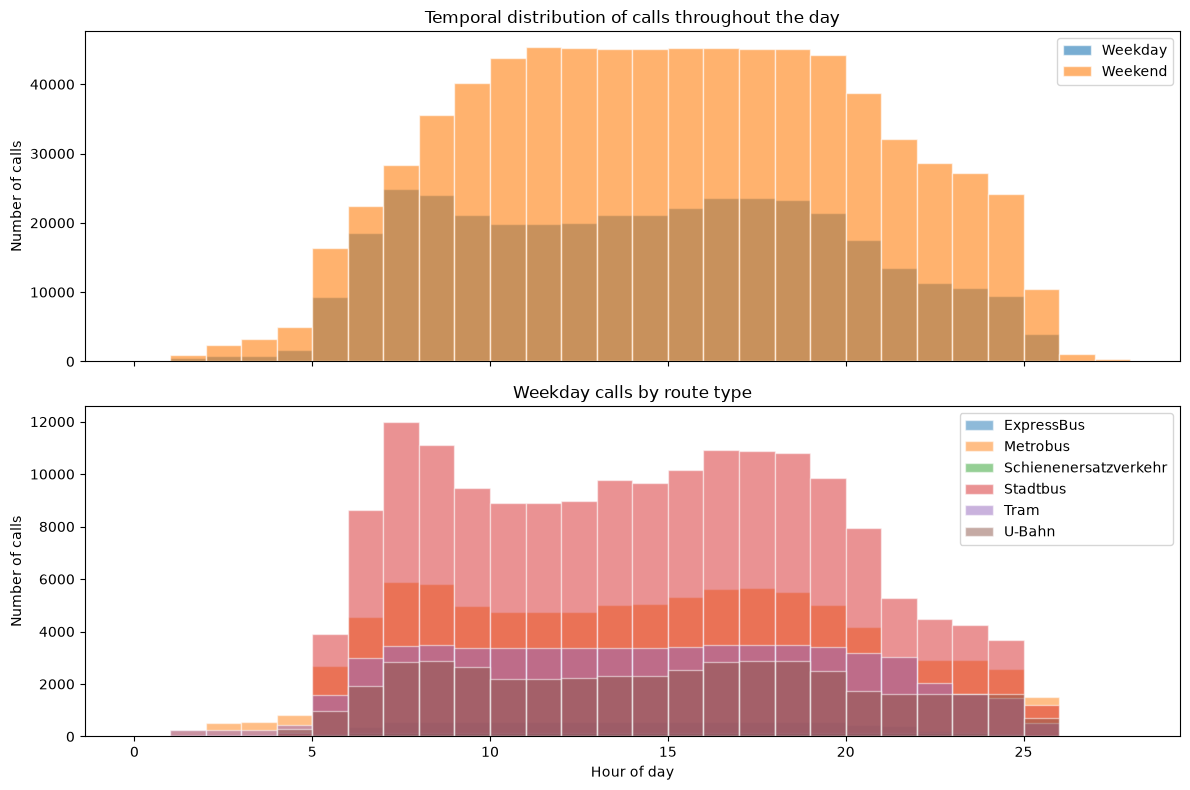

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: weekday vs weekend
for day, grp in calls.groupby('day_type'):
    ax1.hist(grp['hour'], bins=np.arange(0, 29), alpha=0.6, label=day, edgecolor='white')
ax1.set_ylabel('Number of calls')
ax1.set_title('Temporal distribution of calls throughout the day')
ax1.legend()

# Bottom: by route type (weekday)
weekday = calls[calls['day_type'] == 'Weekday']
for desc, grp in weekday.groupby('route_desc'):
    ax2.hist(grp['hour'], bins=np.arange(0, 29), alpha=0.5, label=desc, edgecolor='white')
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Number of calls')
ax2.set_title('Weekday calls by route type')
ax2.legend()

plt.tight_layout()
plt.show()

In [22]:
trips['service_id'].value_counts()

service_id
SWE    35237
SWD    18300
Name: count, dtype: int64

The result of double the calls on weekends seems odd but the dataset contains roughly twice as many weekend trips (35k) as weekday trips (18k), likely because MVG encodes more schedule variants on weekend service; this is reflected in the call counts but does not affect the temporal distributions.

**Problem 1.5**

In [23]:
# Weekday calls only
weekday_calls = calls[calls['day_type'] == 'Weekday']

# Calls per station
calls_per_station = (
    weekday_calls
    .groupby('station')
    .size()
    .reset_index(name='num_calls')
    .merge(stops[['stop_id', 'stop_name']], left_on='station', right_on='stop_id')
    .drop(columns='stop_id')
    .sort_values('num_calls', ascending=False)
    .reset_index(drop=True)
)

calls_per_station.head(10)

,station,num_calls,stop_name
0,de:09162:50,3057,Sendlinger Tor
1,de:09162:1,2546,Karlsplatz (Stachus)
2,de:09162:5,2364,Ostbahnhof
3,de:09162:6,2340,Hauptbahnhof
4,de:09162:1030,2083,Neuperlach Zentrum
5,de:09162:60,1929,Odeonsplatz
6,de:09162:500,1856,Münchner Freiheit
7,de:09162:400,1779,Scheidplatz
8,de:09162:10,1716,Pasing Bf.
9,de:09162:580,1712,Max-Weber-Platz


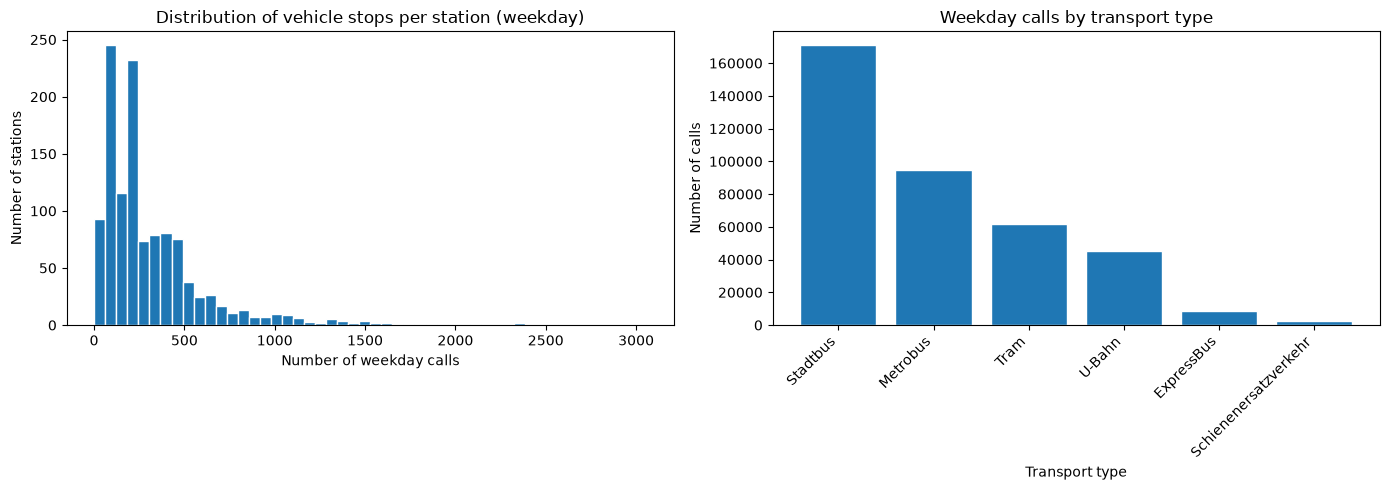

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of calls per station
ax1.hist(calls_per_station['num_calls'], bins=50, edgecolor='white')
ax1.set_xlabel('Number of weekday calls')
ax1.set_ylabel('Number of stations')
ax1.set_title('Distribution of vehicle stops per station (weekday)')

# Right: total calls by route type
calls_by_type = weekday_calls.groupby('route_desc').size().sort_values(ascending=False)
ax2.bar(calls_by_type.index, calls_by_type.values, edgecolor='white')
ax2.set_xlabel('Transport type')
ax2.set_ylabel('Number of calls')
ax2.set_title('Weekday calls by transport type')
ax2.set_xticks(range(len(calls_by_type)))
ax2.set_xticklabels(calls_by_type.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()